In [1]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
from functools import partial

from statsmodels.api import OLS
import sklearn.model_selection as skm
import sklearn.linear_model as skl
from sklearn.preprocessing import StandardScaler

from ISLP import load_data
from ISLP.models import ModelSpec as MS

from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

from ISLP.models import \
     (Stepwise,
      sklearn_selected,
      sklearn_selection_path)

# from l0bnb import fit_path


In [2]:
Hitters = load_data('Hitters')
Hitters.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [3]:
Hitters.shape

(322, 20)

In [4]:
np.isnan(Hitters['Salary']).sum()

np.int64(59)

In [5]:
Hitters = Hitters.dropna();
Hitters.shape

(263, 20)

In [6]:
# while comparing the error rate across different models with different number of variables, training set RSS and R^2 cannot be used
# methods for this include Cp, Akaike information criterion (AIC), Bayesian information Cp criterion (BIC), and adjusted R2

# Cp = 1 / n (RSS + 2dsigma^2)
# by default sklearn tries to maximize the score, hence we caluclate the negativeCp

def negativeCp(sigma_sqr, estimator, X, Y):
    n, p = X.shape
    Yhat = estimator.predict(X)
    RSS = np.sum((Y - Yhat)**2)
    return -(RSS + 2 * p * sigma_sqr) / n 

In [7]:
design = MS(Hitters.columns.drop('Salary')).fit(Hitters)
Y = np.array(Hitters['Salary'])
X = design.transform(Hitters)
res = OLS(Y,X).fit()
# variance of residuals, average squared error after adjusting for model complexity
sigma_square = OLS(Y,X).fit().scale

In [8]:
res?

Type:            RegressionResultsWrapper
String form:     <statsmodels.regression.linear_model.RegressionResultsWrapper object at 0x1469e0ad0>
File:            /opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py
Docstring:      
Results class for for an OLS model.

Parameters
----------
model : RegressionModel
    The regression model instance.
params : ndarray
    The estimated parameters.
normalized_cov_params : ndarray
    The normalized covariance parameters.
scale : float
    The estimated scale of the residuals.
cov_type : str
    The covariance estimator used in the results.
cov_kwds : dict
    Additional keywords used in the covariance specification.
use_t : bool
    Flag indicating to use the Student's t in inference.
**kwargs
    Additional keyword arguments used to initialize the results.

See Also
--------
RegressionResults
    Results store for WLS and GLW models.

Notes
-----
Most of the methods and attributes are inherited from RegressionR

In [9]:
res.params

intercept       163.103588
AtBat            -1.979873
Hits              7.500768
HmRun             4.330883
Runs             -2.376210
RBI              -1.044962
Walks             6.231286
Years            -3.489054
CAtBat           -0.171340
CHits             0.133991
CHmRun           -0.172861
CRuns             1.454305
CRBI              0.807709
CWalks           -0.811571
League[N]        62.599423
Division[W]    -116.849246
PutOuts           0.281893
Assists           0.371069
Errors           -3.360760
NewLeague[N]    -24.762325
dtype: float64

In [10]:
neg_Cp = partial(negativeCp, sigma_square)

In [11]:
# Stepwise - ISLP module
# Stepwise.first_peak() - forward stepwise until any further additions do not result in improvement of evaluation score
# Stepwise.fixed_steps() - fixed number of stepwise search
strategy = Stepwise.first_peak(design,
                               direction='forward',
                               max_terms=len(design.terms))

In [12]:
# sklearn_selected takes a model from statsmodels along with a search strategy and selects a model with its fit method
hitters_MSE = sklearn_selected(OLS, strategy)
hitters_MSE.fit(Hitters, Y)
hitters_MSE.selected_state_
# without a scoring mechanism, it uses all the predictors in the dataset

('Assists',
 'AtBat',
 'CAtBat',
 'CHits',
 'CHmRun',
 'CRBI',
 'CRuns',
 'CWalks',
 'Division',
 'Errors',
 'Hits',
 'HmRun',
 'League',
 'NewLeague',
 'PutOuts',
 'RBI',
 'Runs',
 'Walks',
 'Years')

In [13]:
# we use the negative Cp as scoring mechanism, and we shall see less number of predictors being used to fit the final model
hitters_Cp = sklearn_selected(OLS,
                               strategy,
                               scoring = neg_Cp)
hitters_Cp.fit(Hitters, Y)
hitters_Cp.selected_state_

('Assists',
 'AtBat',
 'CAtBat',
 'CRBI',
 'CRuns',
 'CWalks',
 'Division',
 'Hits',
 'PutOuts',
 'Walks')

In [14]:
"""
what we did so far - 
we calculate the sigma_square - variance of the entire dataset
why entire dataset? because it will vary for different models and not suitable for baseline variance of the data

then we selected a strategy to select the best predictors
we used forward stepwise subset selection

sklearn_selected accepts the model, strategy and scoring mechanism to find the best selected predictors

neg_Cp -> why partial? 
because sklearn scoring accepts only 3 params. but we have 4 params and we reduce it by using partial()
ISLP wraps the actual sklearn scoring function
"""

'\nwhat we did so far - \nwe calculate the sigma_square - variance of the entire dataset\nwhy entire dataset? because it will vary for different models and not suitable for baseline variance of the data\n\nthen we selected a strategy to select the best predictors\nwe used forward stepwise subset selection\n\nsklearn_selected accepts the model, strategy and scoring mechanism to find the best selected predictors\n\nneg_Cp -> why partial? \nbecause sklearn scoring accepts only 3 params. but we have 4 params and we reduce it by using partial()\nISLP wraps the actual sklearn scoring function\n'

In [15]:
# choosing cross validation method to select predictors in forward selection

In [16]:
strategy = Stepwise.fixed_steps(design,
                                len(design.terms),
                                direction='forward')

# ISLP wrapper sklearn_selection_path - stores the full path of models found in forward selection 
full_path = sklearn_selection_path(OLS, strategy)

full_path.fit(Hitters, Y)
Yhat_in = full_path.predict(Hitters)
Yhat_in.shape

(263, 20)

In [17]:
# total 20 steps

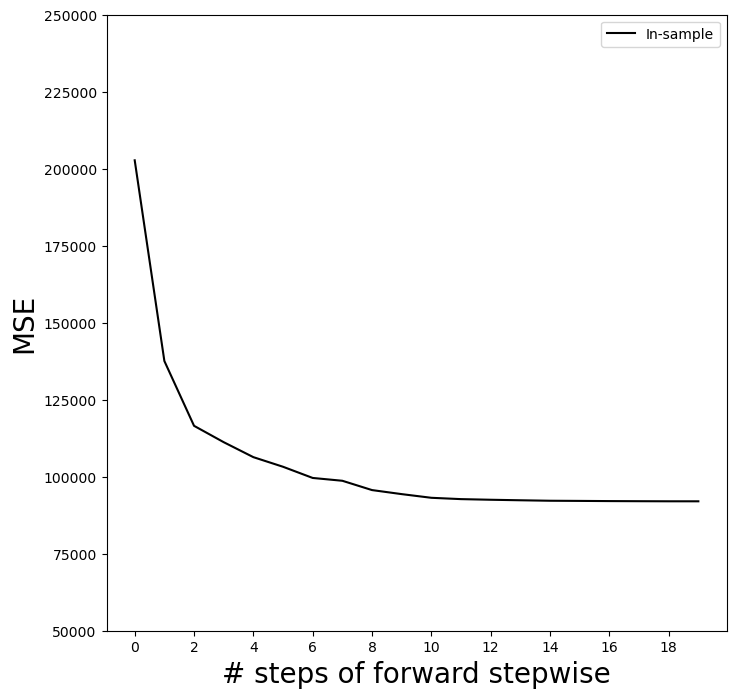

In [18]:
mse_fig, ax = subplots(figsize=(8,8))
insample_mse = ((Yhat_in - Y[:,None])**2).mean(0)
n_steps = insample_mse.shape[0]
ax.plot(np.arange(n_steps), insample_mse, 'k', label='In-sample')
ax.set_ylabel('MSE', fontsize=20)
ax.set_xlabel('# steps of forward stepwise', fontsize=20)
ax.set_xticks(np.arange(n_steps)[::2])
ax.legend()
ax.set_ylim([50000,250000]);

In [19]:
# We must use only the training observations to perform all aspects of model-fitting — including variable selection

In [20]:
K = 5
kfold = skm.KFold(K, random_state=0, shuffle=True)
Yhat_cv = skm.cross_val_predict(full_path, Hitters, Y, cv=kfold)
Yhat_cv.shape

(263, 20)